In [15]:
# =========================
# Cell 1: Imports + config
# =========================
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Point this to your eval_results directory
directory_path = "runs/qwen35_9b_robot_aug_all/eval_results/"

json_files = [
    f for f in glob.glob(os.path.join(directory_path, "*.json"))
    if os.path.basename(f) != "all_metrics.json"
]

print(f"Found {len(json_files)} result files")
for f in sorted(json_files)[:5]:
    print(" -", os.path.basename(f))

Found 10 result files
 - base_pretrained.json
 - checkpoint-138.json
 - checkpoint-184.json
 - checkpoint-230.json
 - checkpoint-276.json


In [16]:
# ==========================================
# Cell 2: Helpers to read the new file shape
# ==========================================
ALL_FIELDS = ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"]
FIELDS_BY_SUBSET = {
    "combined": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "forklift": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "robot": ["hazard_label", "hazard_present", "zone_relation", "object_state"],
}

def parse_step(filename: str) -> int:
    name = filename.lower()
    if "base" in name:
        return 0
    if "final" in name:
        return 999999

    m = re.search(r"checkpoint[-_]?(\d+)", name)
    if m:
        return int(m.group(1))

    m = re.search(r"[-_](\d+)\.json$", name)
    if m:
        return int(m.group(1))

    return -1

def safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(k)
        if cur is None:
            return default
    return cur

def get_field_f1(subset_metrics, field):
    return safe_get(subset_metrics, "per_field_metrics", field, "macro_f1", default=np.nan)

def get_field_fp(subset_metrics, field):
    labels = safe_get(subset_metrics, "per_field_metrics", field, "labels", default={}) or {}
    return sum((info or {}).get("fp", 0) for info in labels.values())

def build_summary_row(file_path, content):
    filename = os.path.basename(file_path)
    metrics = content.get("metrics", {})
    row = {
        "checkpoint": filename.replace(".json", ""),
        "filename": filename,
        "step": parse_step(filename),
        "adapter_name": metrics.get("adapter_name"),
        "inference_time_sec": metrics.get("inference_time_sec", np.nan),
        "samples_per_sec": metrics.get("samples_per_sec", np.nan),
    }

    for subset in ["combined", "forklift", "robot"]:
        subset_metrics = safe_get(metrics, subset, default=None)
        if subset_metrics is None:
            subset_metrics = safe_get(metrics, "by_task", subset, default={}) or {}

        row[f"{subset}_total_samples"] = subset_metrics.get("total_samples", np.nan)
        row[f"{subset}_exact_match_accuracy"] = subset_metrics.get("exact_match_accuracy", np.nan)
        row[f"{subset}_relevant_field_accuracy"] = subset_metrics.get("relevant_field_accuracy", np.nan)
        row[f"{subset}_parse_failures"] = subset_metrics.get("parse_failures", np.nan)
        row[f"{subset}_gt_parse_failures"] = subset_metrics.get("ground_truth_parse_failures", np.nan)
        row[f"{subset}_hazard_f1"] = safe_get(subset_metrics, "hazard_present_binary", "f1", default=np.nan)
        row[f"{subset}_hazard_recall"] = safe_get(subset_metrics, "hazard_present_binary", "recall", default=np.nan)
        row[f"{subset}_hazard_precision"] = safe_get(subset_metrics, "hazard_present_binary", "precision", default=np.nan)

        for field in ALL_FIELDS:
            row[f"{subset}_{field}_acc"] = safe_get(subset_metrics, "per_field_accuracy", field, default=np.nan)
            row[f"{subset}_{field}_f1"] = get_field_f1(subset_metrics, field)
            row[f"{subset}_{field}_fp"] = get_field_fp(subset_metrics, field)

    return row

summary_rows = []

for file_path in json_files:
    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)
    summary_rows.append(build_summary_row(file_path, content))

summary_df = pd.DataFrame(summary_rows).sort_values(["step", "checkpoint"]).reset_index(drop=True)
summary_df.head()

,checkpoint,filename,step,adapter_name,inference_time_sec,samples_per_sec,combined_total_samples,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_parse_failures,...,robot_hazard_present_fp,robot_zone_relation_acc,robot_zone_relation_f1,robot_zone_relation_fp,robot_object_state_acc,robot_object_state_f1,robot_object_state_fp,robot_object_direction_acc,robot_object_direction_f1,robot_object_direction_fp
0,base_pretrained,base_pretrained.json,0,base_pretrained,3433.09,0.1826,627,0.0207,0.2133,0,...,540,0.0447,0.0302,599,0.5311,0.4133,294,NaN,NaN,0
1,checkpoint-46,checkpoint-46.json,46,checkpoint-46,3198.62,0.1960,627,0.8612,0.8959,0,...,87,0.9522,0.4877,30,0.9091,0.4762,57,NaN,NaN,0
2,checkpoint-92,checkpoint-92.json,92,checkpoint-92,3218.09,0.1948,627,0.9187,0.9390,0,...,51,0.9522,0.4877,30,0.9665,0.8781,21,NaN,NaN,0
3,checkpoint-138,checkpoint-138.json,138,checkpoint-138,3199.79,0.1960,627,0.9314,0.9486,0,...,43,0.9649,0.7159,22,0.9665,0.8781,21,NaN,NaN,0
4,checkpoint-184,checkpoint-184.json,184,checkpoint-184,3193.92,0.1963,627,0.9250,0.9438,0,...,47,0.9665,0.7770,21,0.9585,0.8411,26,NaN,NaN,0


In [17]:
# ==================================
# Cell 3: Quick summary table to use
# ==================================
core_cols = [
    "checkpoint", "step",
    "combined_exact_match_accuracy", "combined_relevant_field_accuracy", "combined_hazard_f1",
    "forklift_exact_match_accuracy", "forklift_relevant_field_accuracy", "forklift_hazard_f1",
    "robot_exact_match_accuracy", "robot_relevant_field_accuracy", "robot_hazard_f1",
    "samples_per_sec"
]

display(summary_df[core_cols].round(4))

,checkpoint,step,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_hazard_f1,forklift_exact_match_accuracy,forklift_relevant_field_accuracy,forklift_hazard_f1,robot_exact_match_accuracy,robot_relevant_field_accuracy,robot_hazard_f1,samples_per_sec
0,base_pretrained,0,0.0207,0.2133,0.0000,None,None,NaN,0.0207,0.2133,0.0000,0.1826
1,checkpoint-46,46,0.8612,0.8959,0.9254,None,None,NaN,0.8612,0.8959,0.9254,0.1960
2,checkpoint-92,92,0.9187,0.9390,0.9549,None,None,NaN,0.9187,0.9390,0.9549,0.1948
3,checkpoint-138,138,0.9314,0.9486,0.9616,None,None,NaN,0.9314,0.9486,0.9616,0.1960
4,checkpoint-184,184,0.9250,0.9438,0.9579,None,None,NaN,0.9250,0.9438,0.9579,0.1963
5,checkpoint-230,230,0.9394,0.9545,0.9660,None,None,NaN,0.9394,0.9545,0.9660,0.1952
6,checkpoint-276,276,0.9506,0.9629,0.9717,None,None,NaN,0.9506,0.9629,0.9717,0.1960
7,checkpoint-322,322,0.9474,0.9605,0.9698,None,None,NaN,0.9474,0.9605,0.9698,0.1977
8,checkpoint-368,368,0.9522,0.9641,0.9727,None,None,NaN,0.9522,0.9641,0.9727,0.1962
9,checkpoint-414,414,0.9617,0.9713,0.9781,None,None,NaN,0.9617,0.9713,0.9781,0.1922


In [18]:
from adjustText import adjust_text

# =======================================================
# Plot helpers with automatic label de-overlap
# =======================================================
def annotate_series(x_vals, y_vals, texts, fmt="{:.2f}", fontsize=8):
    for x, y in zip(x_vals, y_vals):
        if pd.isna(y):
            continue
        txt = plt.text(
            x, y, fmt.format(y),
            fontsize=fontsize,
            ha="center",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2)
        )
        texts.append(txt)


def plot_metric_family(df, subset, metric_suffix, title=None, figsize=(14, 5)):
    valid_fields = []
    for field in FIELDS_BY_SUBSET[subset]:
        col = f"{subset}_{field}_{metric_suffix}"
        if col in df.columns and df[col].notna().any():
            valid_fields.append((field, col))

    if not valid_fields:
        print(f"No data to plot for {subset} / {metric_suffix}")
        return

    plt.figure(figsize=figsize)
    texts = []

    for field, col in valid_fields:
        label = field.replace("_", " ").title()
        plt.plot(df["checkpoint"], df[col], marker="o", linewidth=1.8, label=label)

        fmt = "{:.0f}" if metric_suffix == "fp" else "{:.2f}"
        annotate_series(df["checkpoint"], df[col], texts, fmt=fmt)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    if title is None:
        title = f"{subset.title()} - {metric_suffix.upper()}"

    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel(metric_suffix.upper())
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_overall_metrics(df, subset, figsize=(14, 5)):
    cols = [
        f"{subset}_exact_match_accuracy",
        f"{subset}_relevant_field_accuracy",
        f"{subset}_hazard_f1",
    ]
    labels = ["Exact Match", "Relevant Field Acc", "Hazard F1"]

    plt.figure(figsize=figsize)
    texts = []

    for col, label in zip(cols, labels):
        if col in df.columns and df[col].notna().any():
            plt.plot(df["checkpoint"], df[col], marker="o", linewidth=2, label=label)
            annotate_series(df["checkpoint"], df[col], texts, fmt="{:.2f}")

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    plt.title(f"{subset.title()} - Overall Scores", fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

0 [-0.83320733  0.09189067]
10 [ 0.41030889 -0.55149354]
1 [-0.34544591  0.91774068]
11 [0.06396318 0.04245411]
2 [-0.65813376 -0.86128286]
12 [-0.44690546 -0.90360013]
3 [-0.96705932 -0.84624419]
13 [ 0.45127217 -0.6202635 ]
4 [-0.04984272  0.13573157]
14 [-0.17924262  0.03783409]
5 [-0.66014588  0.62897867]
15 [0.56184238 0.31781215]
6 [-0.56761559 -0.4399166 ]
16 [ 0.12597428 -0.95609318]
7 [-0.72798786 -0.40322996]
17 [-0.52118568 -0.25637704]
8 [ 0.086195   -0.46846213]
18 [-0.60994828  0.12944353]
9 [0.96782383 0.47562509]
19 [-0.45367838 -0.39211214]


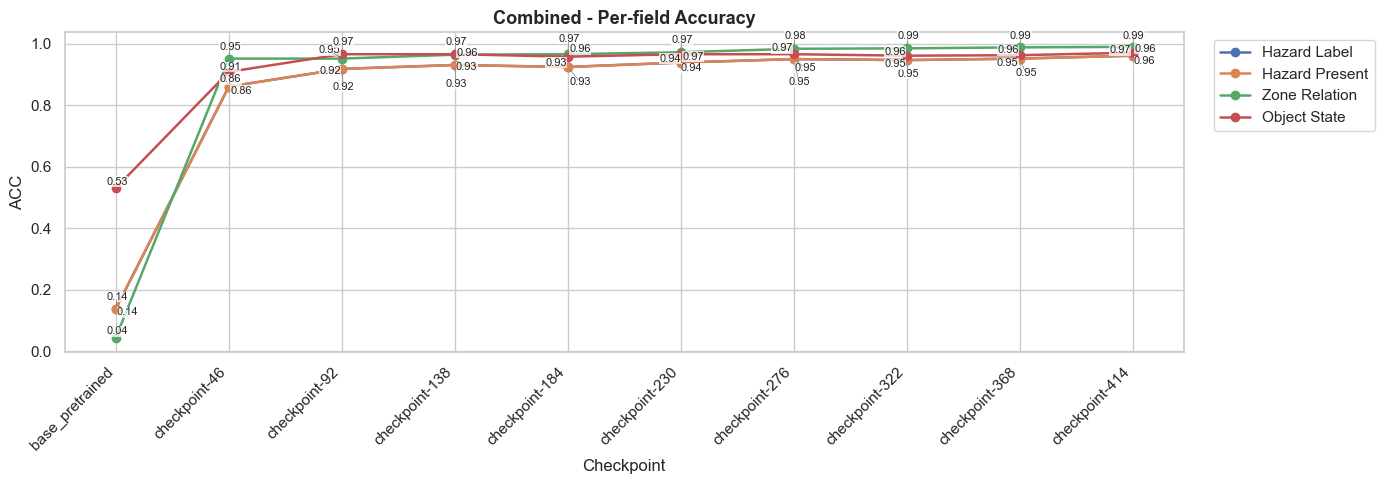

0 [-0.29357601 -0.33142595]
10 [-0.2728312 -0.6284801]
1 [-0.61485153  0.53527617]
11 [0.04057259 0.67268665]
2 [-0.73769392  0.7840893 ]
12 [-0.26684168  0.38386344]
3 [ 0.82156297 -0.9270217 ]
13 [ 0.78912465 -0.30039444]
4 [ 0.86971523 -0.88973266]
14 [-0.90191336  0.71927168]
5 [-0.89277999 -0.69936184]
15 [ 0.77987135 -0.79405264]
6 [0.9787853  0.32383215]
16 [0.64392082 0.93133905]
7 [-0.96661476 -0.10499948]
17 [0.84695861 0.40221897]
8 [-0.69839793 -0.33070213]
18 [0.72600506 0.51068576]
9 [0.65068019 0.23309352]
19 [-0.09622652 -0.74199143]


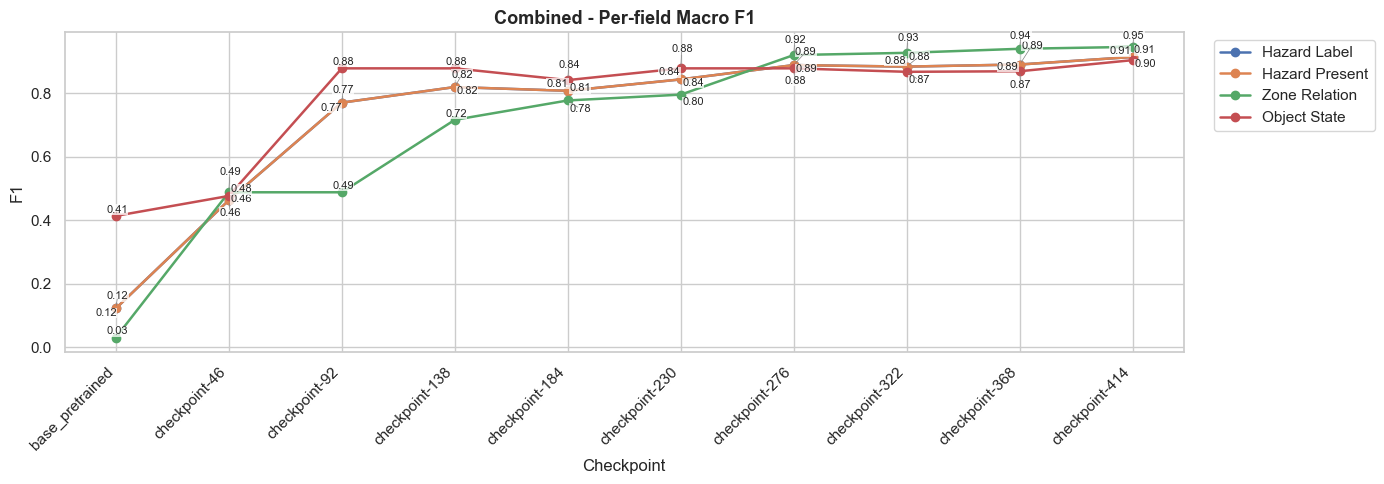

0 [0.07114353 0.50995603]
10 [-0.47483591  0.37059546]
1 [ 0.06629313 -0.43985754]
11 [ 0.82054999 -0.08075327]
2 [-0.67975927 -0.96730066]
12 [0.28348219 0.75299846]
3 [-0.82010484  0.44640915]
13 [-0.99842757 -0.19023491]
4 [-0.17661679 -0.39559463]
14 [ 0.54628427 -0.62269437]
5 [0.61709192 0.44885456]
15 [-0.83136628 -0.72525182]
6 [0.23310865 0.12351654]
16 [-0.81612417  0.81184582]
7 [-0.152624    0.51697114]
17 [-0.21906332  0.98205561]
8 [0.92391024 0.48434562]
18 [ 0.14859617 -0.49544595]
9 [-0.51476313  0.19188522]
19 [0.72636809 0.5551187 ]


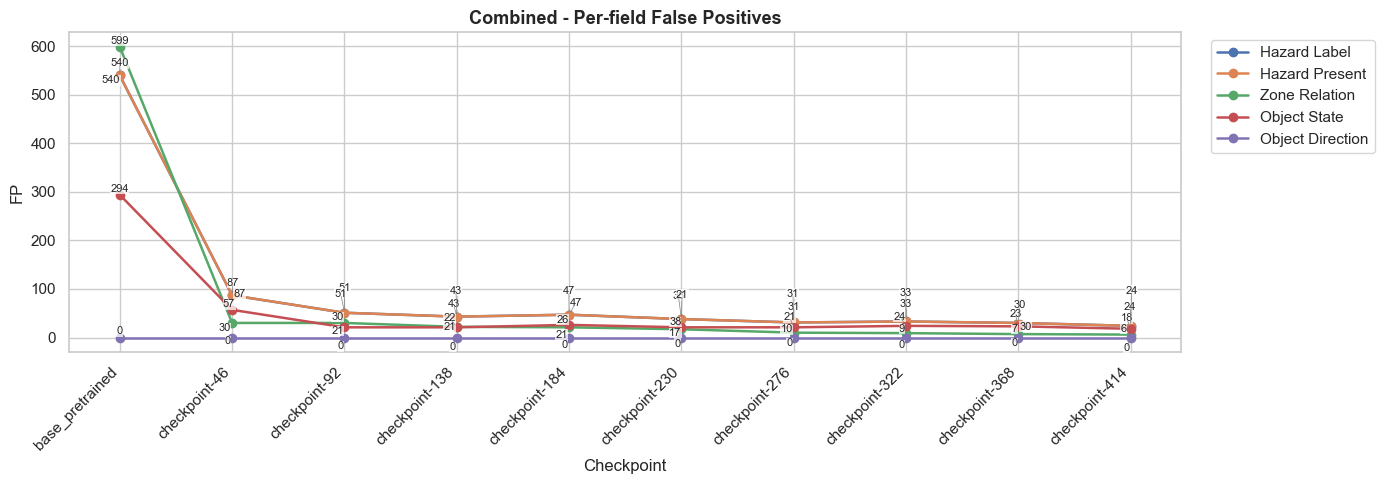

No data to plot for forklift / acc
No data to plot for forklift / f1
0 [ 0.88535866 -0.61109565]
10 [-0.10809894  0.70766057]
20 [0.3637797  0.02430577]
30 [-0.23443464 -0.58913068]
40 [-0.67878381 -0.39416422]
1 [0.15334472 0.1363154 ]
11 [ 0.7578212  -0.94218525]
21 [-0.91026775 -0.4474871 ]
31 [0.20404218 0.53053944]
41 [-0.03672408  0.81180944]
2 [0.08269277 0.00928389]
12 [0.69028914 0.79096552]
22 [-0.18268279  0.58084373]
32 [ 0.67122051 -0.16253338]
42 [ 0.10591957 -0.60411397]
3 [ 0.48710081 -0.39576219]
13 [0.143213   0.95204507]
23 [ 0.85104662 -0.38579973]
33 [-0.35798494 -0.51541312]
43 [-0.38306902 -0.82462273]
4 [0.52706832 0.49710054]
14 [ 0.85116578 -0.95347461]
24 [0.70692554 0.74776937]
34 [-0.1933828  -0.21161368]
44 [ 0.36437152 -0.58449441]
5 [-0.77344344 -0.79547026]
15 [0.7849583  0.94751298]
25 [-0.72359747 -0.26078897]
35 [ 0.10947422 -0.9869971 ]
45 [0.6193381  0.30304656]
6 [-0.78752173  0.77003937]
16 [ 0.79273727 -0.3934664 ]
26 [ 0.12330415 -0.7671747 ]
3

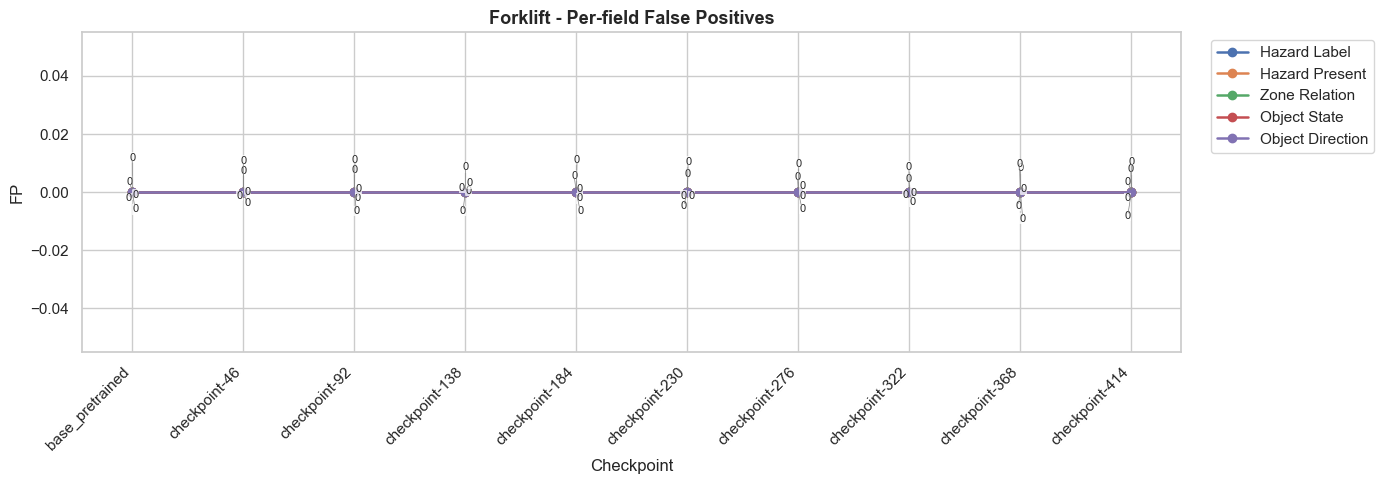

0 [-0.96095875 -0.69202745]
10 [-0.16821734  0.27984756]
1 [ 0.3860591  -0.76157577]
11 [-0.71973773  0.55347456]
2 [-0.52085232  0.61519199]
12 [-0.31864678  0.41937491]
3 [0.6453084  0.79108075]
13 [-0.59448988  0.52064532]
4 [-0.86393722 -0.94294401]
14 [-0.55947046 -0.24770859]
5 [-0.92204374 -0.19806056]
15 [-0.7952479   0.68893601]
6 [-0.74395577  0.85949994]
16 [-0.19045334 -0.20711051]
7 [-0.74009649 -0.38431642]
17 [-0.63263277 -0.53245907]
8 [ 0.00302328 -0.12472341]
18 [0.68612588 0.18191146]
9 [-0.24675171  0.04215546]
19 [ 0.89668519 -0.27130527]


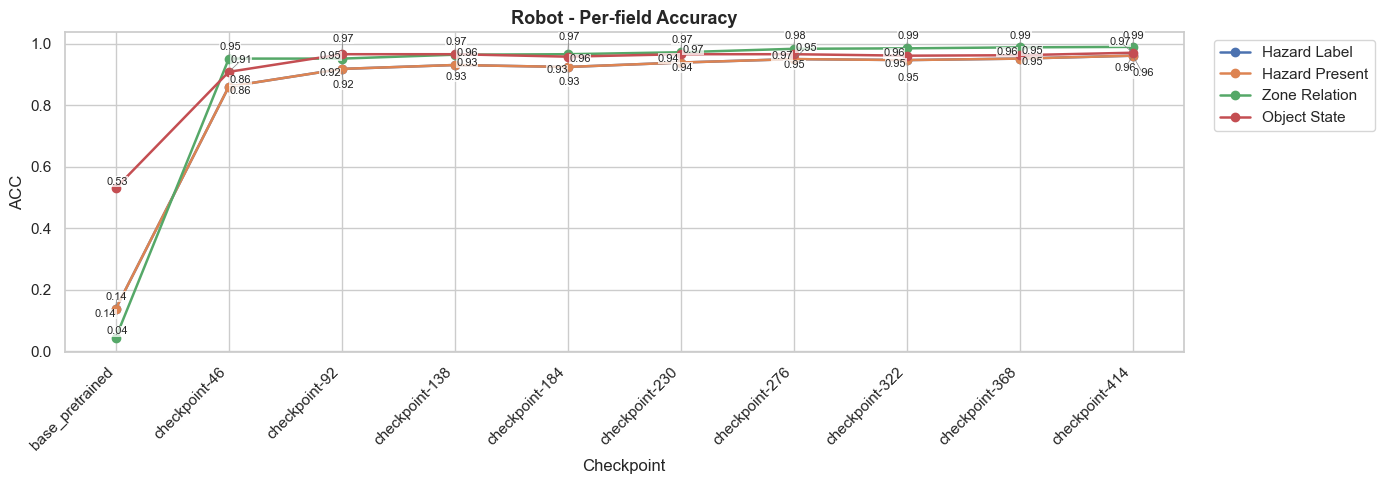

0 [ 0.43899176 -0.43880316]
10 [ 0.75352867 -0.73623881]
1 [ 0.16268963 -0.85075938]
11 [0.16126902 0.39526269]
2 [0.59228252 0.80794336]
12 [ 0.92053812 -0.55092844]
3 [ 0.91718452 -0.97594142]
13 [-0.28684583 -0.94690959]
4 [-0.72763976 -0.52114702]
14 [0.31016483 0.64061144]
5 [-0.45466059 -0.49501083]
15 [ 0.74304547 -0.82667668]
6 [0.55262928 0.38197903]
16 [-0.04441104  0.45874683]
7 [0.99130796 0.63076349]
17 [0.533165  0.0286429]
8 [ 0.67517171 -0.29981824]
18 [ 0.91472402 -0.02808184]
9 [-0.0976677   0.75051291]
19 [ 0.33113502 -0.06473734]


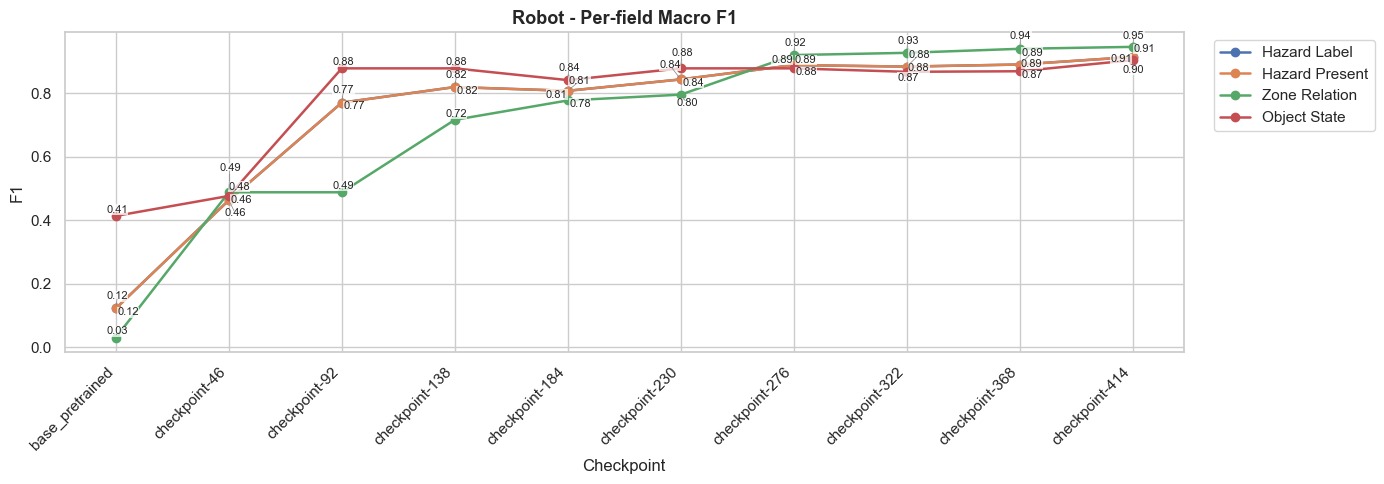

0 [-0.93214393  0.73858625]
10 [-0.57490154 -0.28129953]
1 [-0.75087958 -0.93506612]
11 [-0.19983415 -0.77497917]
2 [-0.00197582 -0.52217452]
12 [0.14827088 0.14341295]
3 [ 0.3253702  -0.55620139]
13 [0.06894226 0.48809479]
4 [-0.27920545  0.01390782]
14 [ 0.74661423 -0.1910264 ]
5 [0.72366385 0.47724879]
15 [-0.48255207 -0.68984477]
6 [-0.7975593   0.92050879]
16 [-0.90810867  0.46724902]
7 [0.64133009 0.34924548]
17 [ 0.60400077 -0.67092039]
8 [ 0.31448014 -0.38808996]
18 [0.98967824 0.32541811]
9 [-0.94750995  0.92548643]
19 [-0.0507909   0.02857102]


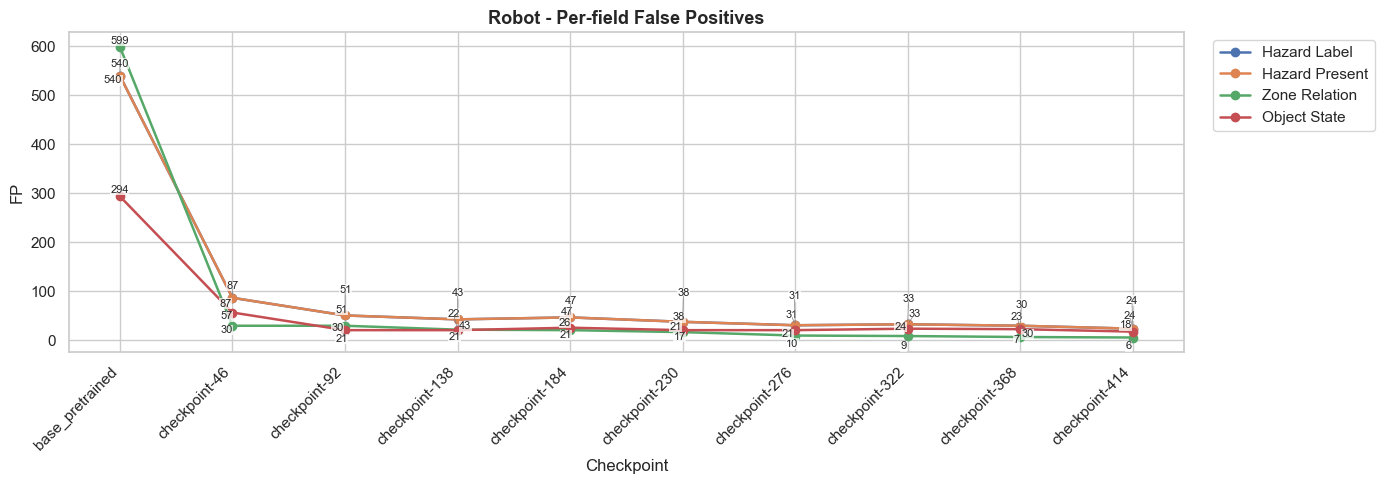

In [19]:
# ============================================
# Cell 6: Per-field ACC / F1 / FP for each set
# ============================================
plot_metric_family(summary_df, "combined", "acc", "Combined - Per-field Accuracy")
plot_metric_family(summary_df, "combined", "f1",  "Combined - Per-field Macro F1")
plot_metric_family(summary_df, "combined", "fp",  "Combined - Per-field False Positives")

plot_metric_family(summary_df, "forklift", "acc", "Forklift - Per-field Accuracy")
plot_metric_family(summary_df, "forklift", "f1",  "Forklift - Per-field Macro F1")
plot_metric_family(summary_df, "forklift", "fp",  "Forklift - Per-field False Positives")

plot_metric_family(summary_df, "robot", "acc", "Robot - Per-field Accuracy")
plot_metric_family(summary_df, "robot", "f1",  "Robot - Per-field Macro F1")
plot_metric_family(summary_df, "robot", "fp",  "Robot - Per-field False Positives")

In [20]:
# ===================================================
# Cell 7: Load per-sample rows from all result files
# ===================================================
sample_rows = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    checkpoint = filename.replace(".json", "")
    step = parse_step(filename)

    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)

    per_sample = content.get("per_sample", [])
    for s in per_sample:
        gt = s.get("ground_truth") or {}
        pred = s.get("prediction_parsed") or {}
        meta = s.get("meta") or {}
        field_matches = s.get("field_matches") or {}

        row = {
            "checkpoint": checkpoint,
            "step": step,
            "sample_id": s.get("sample_id"),
            "task": s.get("task"),
            "exact_match": s.get("exact_match"),
            "ground_truth_parse_failed": s.get("ground_truth_parse_failed"),
            "inference_time_sec": s.get("inference_time_sec"),
            "hard_negative_bucket": s.get("hard_negative_bucket"),
            "prediction_raw": s.get("prediction_raw"),
            "ground_truth_text": s.get("ground_truth_text"),
            "source_video_id": meta.get("source_video_id"),
            "clip_start_sec": meta.get("clip_start_sec"),
            "clip_end_sec": meta.get("clip_end_sec"),
            "anchor_start_sec": meta.get("anchor_start_sec"),
            "anchor_end_sec": meta.get("anchor_end_sec"),
            "is_transition": meta.get("is_transition"),
            "is_ambiguous": meta.get("is_ambiguous"),
        }

        for field in ALL_FIELDS:
            row[f"gt_{field}"] = gt.get(field)
            row[f"pred_{field}"] = pred.get(field)
            row[f"match_{field}"] = field_matches.get(field)

        # True hazard false positive: GT says no, prediction says yes
        row["hazard_fp"] = (gt.get("hazard_present") == "no") and (pred.get("hazard_present") == "yes")

        # True hazard false negative: GT says yes, prediction says no
        row["hazard_fn"] = (gt.get("hazard_present") == "yes") and (pred.get("hazard_present") == "no")

        # Useful backup view: negative samples with any mistake
        row["negative_case_error"] = (gt.get("hazard_present") == "no") and (s.get("exact_match") is False)

        sample_rows.append(row)

samples_df = pd.DataFrame(sample_rows).sort_values(["step", "task", "sample_id"]).reset_index(drop=True)
samples_df.head()

,checkpoint,step,sample_id,task,exact_match,ground_truth_parse_failed,inference_time_sec,hard_negative_bucket,prediction_raw,ground_truth_text,...,match_zone_relation,gt_object_state,pred_object_state,match_object_state,gt_object_direction,pred_object_direction,match_object_direction,hazard_fp,hazard_fn,negative_case_error
0,base_pretrained,0,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot,True,False,5.3967,outside_moving,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,True,moving,moving,True,None,None,None,False,False,False
1,base_pretrained,0,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot,True,False,5.3606,outside_moving,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,True,moving,moving,True,None,None,None,False,False,False
2,base_pretrained,0,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot,True,False,5.4293,outside_moving,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,True,moving,moving,True,None,None,None,False,False,False
3,base_pretrained,0,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot,False,False,5.6587,outside_moving,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,True,moving,stationary,False,None,None,None,False,False,True
4,base_pretrained,0,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot,True,False,5.3373,outside_moving,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,True,moving,moving,True,None,None,None,False,False,False


In [21]:
# ===========================================
# Cell 8: Count hazard FPs and FNs by run/task
# ===========================================
fp_fn_summary = (
    samples_df
    .groupby(["checkpoint", "task"], as_index=False)
    .agg(
        hazard_fp_count=("hazard_fp", "sum"),
        hazard_fn_count=("hazard_fn", "sum"),
        negative_case_error_count=("negative_case_error", "sum"),
        total_samples=("sample_id", "count"),
    )
    .sort_values(["checkpoint", "task"])
)

display(fp_fn_summary)

,checkpoint,task,hazard_fp_count,hazard_fn_count,negative_case_error_count,total_samples
0,base_pretrained,robot,0,540,74,627
1,checkpoint-138,robot,42,1,42,627
2,checkpoint-184,robot,42,5,42,627
3,checkpoint-230,robot,38,0,38,627
4,checkpoint-276,robot,23,8,23,627
5,checkpoint-322,robot,22,11,22,627
6,checkpoint-368,robot,24,6,24,627
7,checkpoint-414,robot,19,5,19,627
8,checkpoint-46,robot,87,0,87,627
9,checkpoint-92,robot,51,0,51,627


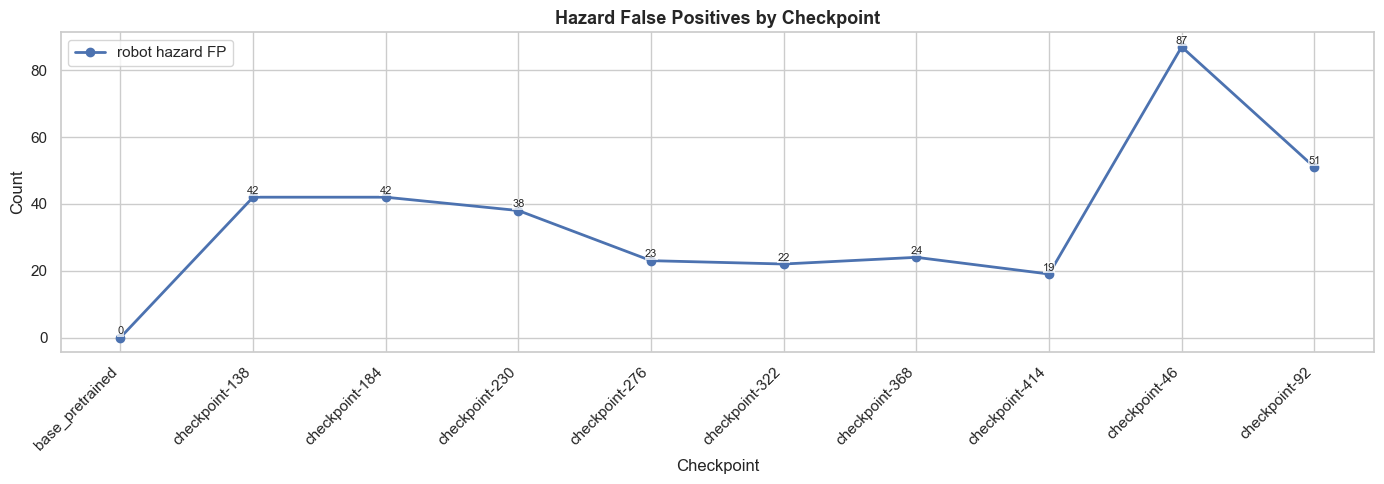

In [22]:
plt.figure(figsize=(14, 5))
texts = []

for task_name, sub_df in fp_fn_summary.groupby("task"):
    plt.plot(
        sub_df["checkpoint"],
        sub_df["hazard_fp_count"],
        marker="o",
        linewidth=2,
        label=f"{task_name} hazard FP"
    )
    annotate_series(sub_df["checkpoint"], sub_df["hazard_fp_count"], texts, fmt="{:.0f}")

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    only_move={"points": "y", "text": "y"},
    force_text=0.8,
    force_points=0.3
)

plt.title("Hazard False Positives by Checkpoint", fontsize=13, fontweight="bold")
plt.xlabel("Checkpoint")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Cell 8A: Ground-truth sample counts per label / per field
# ============================================================
count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        gt_col = f"gt_{field}"
        value = row.get(gt_col, None)

        # Skip robot object_direction since it is not a task field there
        if pd.isna(value) or value is None:
            continue

        count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "ground_truth"
        })

label_counts_df = (
    pd.DataFrame(count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

display(label_counts_df.head(50))

,checkpoint,task,field,label,count_type,num_samples
0,base_pretrained,robot,hazard_label,no_hazard,ground_truth,87
1,base_pretrained,robot,hazard_label,unsafe_machine_proximity,ground_truth,540
2,base_pretrained,robot,hazard_present,no,ground_truth,87
3,base_pretrained,robot,hazard_present,yes,ground_truth,540
4,base_pretrained,robot,object_state,moving,ground_truth,570
5,base_pretrained,robot,object_state,stationary,ground_truth,57
6,base_pretrained,robot,zone_relation,inside,ground_truth,597
7,base_pretrained,robot,zone_relation,outside,ground_truth,30
8,checkpoint-138,robot,hazard_label,no_hazard,ground_truth,87
9,checkpoint-138,robot,hazard_label,unsafe_machine_proximity,ground_truth,540


In [24]:
# ============================================================
# Cell 8B: Prediction sample counts per label / per field
# ============================================================
pred_count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        pred_col = f"pred_{field}"
        value = row.get(pred_col, None)

        if pd.isna(value) or value is None:
            continue

        pred_count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "prediction"
        })

pred_label_counts_df = (
    pd.DataFrame(pred_count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

display(pred_label_counts_df.head(50))

,checkpoint,task,field,label,count_type,num_samples
0,base_pretrained,robot,hazard_label,no_hazard,prediction,627
1,base_pretrained,robot,hazard_present,no,prediction,627
2,base_pretrained,robot,object_state,moving,prediction,338
3,base_pretrained,robot,object_state,stationary,prediction,289
4,base_pretrained,robot,zone_relation,no_worker,prediction,38
5,base_pretrained,robot,zone_relation,outside,prediction,589
6,checkpoint-138,robot,hazard_label,no_hazard,prediction,46
7,checkpoint-138,robot,hazard_label,unsafe_machine_proximity,prediction,581
8,checkpoint-138,robot,hazard_present,no,prediction,46
9,checkpoint-138,robot,hazard_present,yes,prediction,581


In [25]:
# =======================================================
# Cell 10: Sample view for actual hazard false positives
# =======================================================
# Change this if you want a specific checkpoint
selected_checkpoint = summary_df.iloc[-1]["checkpoint"]

fp_cases = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["hazard_fp"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Number of hazard false positives: {len(fp_cases)}")
display(fp_cases.head(20))

Selected checkpoint: checkpoint-414
Number of hazard false positives: 19


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw
5651,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,22.0,27.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5657,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,49.0,54.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5730,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,194.0,199.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5802,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,396.0,401.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5803,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,396.0,401.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5804,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,396.0,401.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5805,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,398.0,403.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5806,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,398.0,403.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5807,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,398.0,403.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5808,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,402.0,407.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."


In [26]:
# ====================================================================
# Cell 11: Backup sample view if hazard FP count is zero for a run
# ====================================================================
# This is useful for runs like "always predicts no hazard",
# where there may be zero hazard FPs but still many wrong negative cases.

negative_errors = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["negative_case_error"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Negative samples with any mistake: {len(negative_errors)}")
display(negative_errors.head(20))

Selected checkpoint: checkpoint-414
Negative samples with any mistake: 19


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw
5651,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,22.0,27.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5657,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,49.0,54.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5730,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,194.0,199.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5802,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,396.0,401.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5803,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,396.0,401.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5804,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,396.0,401.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5805,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,398.0,403.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5806,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,398.0,403.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5807,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,398.0,403.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
5808,checkpoint-414,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,402.0,407.0,no_hazard,unsafe_machine_proximity,no,yes,inside,inside,stationary,moving,None,None,inside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."


In [27]:
# =========================================================
# Cell 12: Optional - inspect one specific sample in detail
# =========================================================
sample_to_inspect = None  # e.g. "fork_금진Camera05_S20251213073941_E20251213074740__000087000_000092000"

if sample_to_inspect:
    display(
        samples_df[samples_df["sample_id"] == sample_to_inspect].T
    )